# Part 6a: Stochastic continuous-time dynamical systems (SDEs)

We introduce **continuous-time** state evolution via **ContinuousTimeStateEvolution** and the **SDESimulator**, and run inference with **filtering** (e.g. EnKF) on a partially observed Lorenz 63 example.

## 6.1 ContinuousTimeStateEvolution: drift, diffusion, and SDEs

In continuous time, the state evolves according to an **Itô SDE**:

$$dX_t = f(X_t, u_t, t)\,dt + L(X_t, u_t, t)\,dW_t$$

where $W_t$ is a vector Brownian motion. We specify:

- **`drift`**: $f(x, u, t)$ — the deterministic part (vector of same dimension as state).
- **`diffusion_coefficient`**: $L(x, u, t)$ — matrix such that the diffusion term is $L\,dW_t$. Shape is `(state_dim, brownian_dim)`.

All three are callables with signature `(x, u, t)`: state `x`, control `u` (or `None`), and time `t`.

## 6.2 Generating data: SDESimulator

To **simulate** a continuous-time model we use **`SDESimulator`** (instead of `DiscreteTimeSimulator`). It integrates the SDE and observes at the given times. We pass `obs_times` directly to the model.

## 6.3 Lorenz 63 with partial observations

Lorenz 63 has state $x = (x_1, x_2, x_3)$ and drift

$$f(x) = \big(\sigma(x_2 - x_1),\, x_1(\rho - x_3) - x_2,\, x_1 x_2 - \beta x_3\big).$$

We take $\sigma=10$, $\beta=8/3$, and sample $\rho$ from a prior. We observe **only the first component** $x_1$ with Gaussian noise: $y_t = H x_t + \varepsilon_t$ with $H = [1, 0, 0]$ and $R = 1^2$. This is **partial observation** and is specified via **`LinearGaussianObservation(H, R)`**. The matrix $H$ has shape `(observation_dim, state_dim)`; here we use `H = [[1, 0, 0]]` so we get one scalar observation per time. Using `LinearGaussianObservation` gives access to **structured inference** methods (EnKF, EKF, UKF) in CD-Dynamax; for more general observation models or non-Gaussian initial conditions, particle filters (e.g. DPF) are available.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive


import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DynamicalModel,
    LinearGaussianObservation,
    SDESimulator,
)

state_dim = 3
observation_dim = 1


def l63_model(obs_times=None, obs_values=None):
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0))
    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(state_dim), covariance_matrix=20.0**2 * jnp.eye(state_dim)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array(
                [
                    10.0 * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - (8.0 / 3.0) * x[2],
                ]
            ),
            diffusion_coefficient=lambda x, u, t: jnp.eye(3),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(observation_dim, state_dim),  # observe only x[0]
            R=jnp.eye(observation_dim),
        ),
    )
    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values)

In [2]:
key = jr.PRNGKey(0)
rho_true = 28.0
obs_times = jnp.arange(0.0, 20.0, 1.0)  # dense observations

predictive = Predictive(
    l63_model,
    params={"rho": jnp.array(rho_true)},
    num_samples=1,
    exclude_deterministic=False,
)
with SDESimulator():
    synthetic = predictive(key, obs_times=obs_times)

# With num_samples=1, leading dim may be present
times = (
    jnp.squeeze(synthetic["times"], axis=0)
    if synthetic["times"].ndim == 2
    else synthetic["times"]
)
states = synthetic["states"][0]  # (T, 3)
observations = synthetic["observations"][0]  # (T, 1)

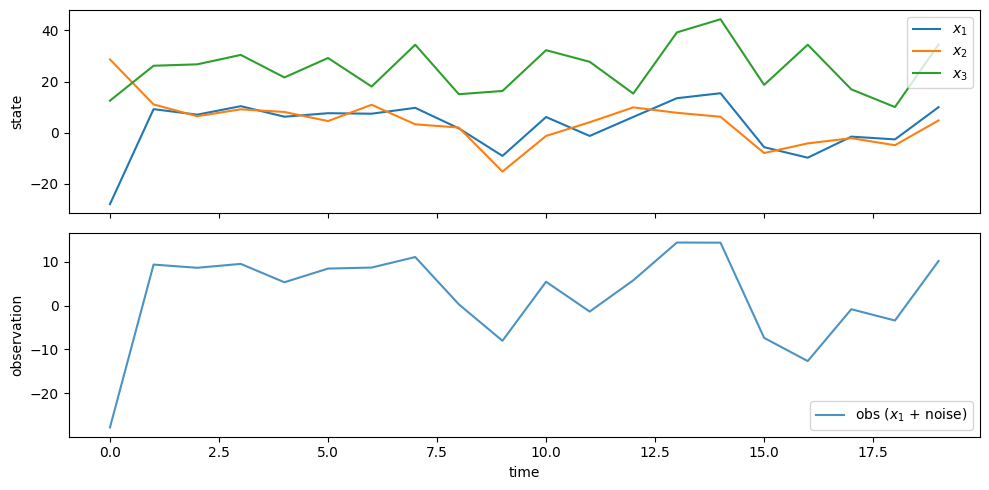

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(times, states[:, 0], label="$x_1$")
axes[0].plot(times, states[:, 1], label="$x_2$")
axes[0].plot(times, states[:, 2], label="$x_3$")
axes[0].set_ylabel("state")
axes[0].legend(loc="upper right")
axes[1].plot(
    times, observations[:, 0], label="obs ($x_1$ + noise)", color="C0", alpha=0.8
)
axes[1].set_ylabel("observation")
axes[1].set_xlabel("time")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6.4 Inference: NUTS + Filtering (EnKF)

For continuous-time models we use **Filter** with a filter supported by CD-Dynamax. The **default** (and a good choice for nonlinear models) is the **EnKF** (ensemble Kalman filter). Other options include **EKF** and **UKF** (both Gaussian approximations), and **DPF** (differentiable particle filter) for non-Gaussian observation models or initial conditions.

We pass the observed values `obs_values` along with `obs_times` to the model for inference.

In [ ]:
import optax
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoMultivariateNormal
# from numpyro.infer import MCMC, NUTS

from dynestyx import Filter
from dynestyx.inference.filters import ContinuousTimeEnKFConfig

obs_values = observations


def filter_conditioned_l63(obs_times=None, obs_values=None):
    with Filter(filter_config=ContinuousTimeEnKFConfig(n_particles=50)):
        return l63_model(obs_times=obs_times, obs_values=obs_values)

num_svi_steps = 1000
num_posterior_samples = 100
guide1 = AutoMultivariateNormal(filter_conditioned_l63, init_scale=1.0)
optimizer = optax.adam(learning_rate=0.1)
svi1 = SVI(filter_conditioned_l63, guide1, optimizer, loss=Trace_ELBO())
svi_result1 = svi1.run(jr.PRNGKey(1), num_steps=num_svi_steps, obs_times=times, obs_values=obs_values)
# print the posterior location and scale
# print("SVI posterior mean:", svi_result1.params["auto_loc"]["rho"])
# print("SVI posterior std:", svi_result1.params["auto_scale"]["rho"])
posterior = Predictive(
    guide1, params=svi_result1.params, num_samples=num_posterior_samples
)(jr.PRNGKey(2))
# print the inferr

# nuts_kernel = NUTS(filter_conditioned_l63)
# mcmc = MCMC(nuts_kernel, num_warmup=100, num_samples=100)
# mcmc.run(jr.PRNGKey(1), obs_times=times, obs_values=observations)
# posterior = mcmc.get_samples()
print("Posterior rho mean:", float(jnp.mean(posterior["rho"])))

print("True rho:", rho_true)

100%|██████████| 100/100 [01:12<00:00,  1.37it/s, init loss: 70.7126, avg. loss [96-100]: 70.3469]


Posterior rho mean: 31.665572268379485
True rho: 28.0


In [5]:
svi_result1.params

{'auto_loc': Array([1.12748297], dtype=float64),
 'auto_scale_tril': Array([[0.85050159]], dtype=float64)}

In [6]:
print("SVI posterior mean:", svi_result1.params["auto_loc"])
print("SVI posterior std:", svi_result1.params["auto_scale_tril"])


SVI posterior mean: [1.12748297]
SVI posterior std: [[0.85050159]]


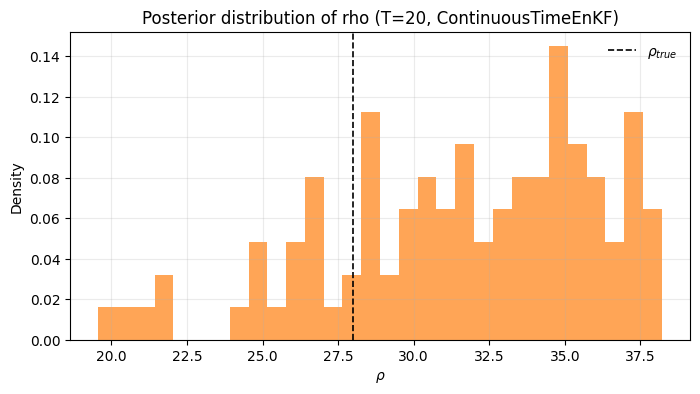

In [7]:
# Plotting the posterior distribution of rho
plt.figure(figsize=(8, 4))
plt.hist(posterior["rho"], bins=30, density=True, alpha=0.7, color="C1")
plt.axvline(rho_true, color='k', ls='--', lw=1.2, label=r'$\rho_{true}$')
plt.xlabel(r'$\rho$')
plt.ylabel('Density')
plt.title('Posterior distribution of rho (T=20, ContinuousTimeEnKF)')
plt.grid(alpha=0.25)
plt.legend(frameon=False)
plt.show()

## 6.5 Full observations and high-frequency, low-noise data

A common special case is **full observations** with **high-frequency, low-noise** measurements. Under that assumption we can **accelerate inference** dramatically at the expense of some bias (depending on how valid the assumption is). See the [deep dive on this topic](../../../deep_dives/l63_speedup_dirac_vs_enkf/) for details.

**Next:** [Part 6b — ODEs](../06b_odes/)